In [22]:
#======================#
#   Import Libraries   #
#======================#

import ROOT
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

RUNS = [983, 1009, 1010, 1011, 1012, 1013, 1516, 1564, 1589, 1614, 1917, 1989]

RUN = 1989
ROI_min, ROI_max = 5000, 8000  # ROI in keV

In [23]:
#===============#
#   Load Data   #
#===============#

f = ROOT.TFile(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Data/PROCESSED/run{RUN}.root")
df = ROOT.RDataFrame("coincidenceEvents", f)

df = df.Filter("isPulser == 0")

events = df.AsNumpy(columns=["energySum", "timeStamp"])

8.390438999999999
From 0.0 to 1.0 hours: 66915.0 counts in ROI
From 1.0 to 2.0 hours: 67910.0 counts in ROI
From 2.0 to 3.0 hours: 67044.0 counts in ROI
From 3.0 to 4.0 hours: 66201.0 counts in ROI
From 4.0 to 5.0 hours: 65910.0 counts in ROI
From 5.0 to 6.0 hours: 65905.0 counts in ROI
From 6.0 to 7.0 hours: 66751.0 counts in ROI
From 7.0 to 8.0 hours: 66745.0 counts in ROI
From 8.0 to 9.0 hours: 67263.0 counts in ROI
From 9.0 to 10.0 hours: 67525.0 counts in ROI
From 10.0 to 11.0 hours: 67239.0 counts in ROI
From 11.0 to 12.0 hours: 66611.0 counts in ROI
From 12.0 to 13.0 hours: 66661.0 counts in ROI
From 13.0 to 14.0 hours: 65988.0 counts in ROI
From 14.0 to 15.0 hours: 65511.0 counts in ROI
From 15.0 to 16.0 hours: 64959.0 counts in ROI
From 16.0 to 17.0 hours: 66599.0 counts in ROI
From 17.0 to 18.0 hours: 67434.0 counts in ROI
From 18.0 to 19.0 hours: 67373.0 counts in ROI
From 19.0 to 20.0 hours: 68129.0 counts in ROI
From 20.0 to 21.0 hours: 67914.0 counts in ROI
From 21.0 to 2

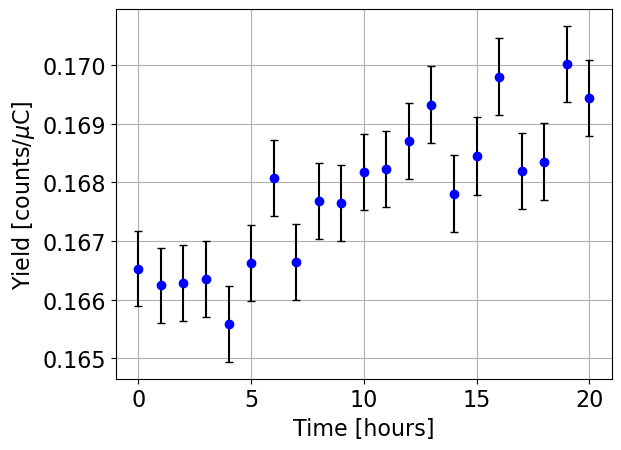

In [24]:
# I want to compute the yield inside the ROI using the timestamp information cutting every 3600s

energies = events["energySum"]
timestamps = events["timeStamp"]/1e8 # convert to seconds
charge_time, charge = np.genfromtxt(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Data/CURRENT/run{RUN}.txt", unpack=True, usecols=(0,1))
# charge = charge * 8390245.876923077/np.sum(charge)
# charge = charge * 8390439/np.sum(charge)
charge = charge * 8390439.0/np.sum(charge)
print(np.sum(charge)/1e6)

t = 0
width = 60*60
temp = []
temp_err = []
while t < timestamps[-1]:
    mask = (timestamps >= t) & (timestamps < t + width)
    energies_in_interval = energies[mask]
    charge_in_interval = float(np.sum(charge[(charge_time >= t) & (charge_time < t + width)]))
    counts_in_ROI = float(np.sum((energies_in_interval >= ROI_min) & (energies_in_interval <= ROI_max)))
    temp.append(counts_in_ROI/charge_in_interval)
    temp_err.append(np.sqrt(counts_in_ROI)/charge_in_interval)
    print(f"From {t/3600:.1f} to {(t + width)/3600:.1f} hours: {counts_in_ROI} counts in ROI")
    t += width

temp_temp = np.arange(len(temp))*width/3600
temp = [float(x) for x in temp]
temp_err = [float(x) for x in temp_err]

plt.errorbar(temp_temp[:-1], temp[:-1], yerr=temp_err[:-1], fmt='o', color='blue', ecolor='black', capsize=3)
plt.grid()
plt.xlabel("Time [hours]")
plt.ylabel(r"Yield [counts/$\mu$C]")
plt.savefig(f"yield_time_run_time.png", dpi=300, bbox_inches='tight')
plt.show()

In [25]:
#########################################################
#   Implement background removal with Covel algorithm   #
#########################################################

def covel(hist, ROI_min, ROI_max, width=100):
    left_side = np.where((hist[1] >= ROI_min - width) & (hist[1] < ROI_min))[0]
    x0 = ROI_min - width/2
    y0 = np.mean(hist[0][left_side])

    right_side = np.where((hist[1] > ROI_max) & (hist[1] <= ROI_max + width))[0]
    x1 = ROI_max + width/2
    y1 = np.mean(hist[0][right_side])

    central_side = np.where((hist[1] >= ROI_min) & (hist[1] <= ROI_max))[0]
    bkg = []
    m = (y1 - y0) / (x1 - x0)
    for i in central_side:
        bkg.append(y0 + m * (hist[1][i] - x0))
    
    
    
    return left_side, x0, y0, right_side, x1, y1, central_side, bkg


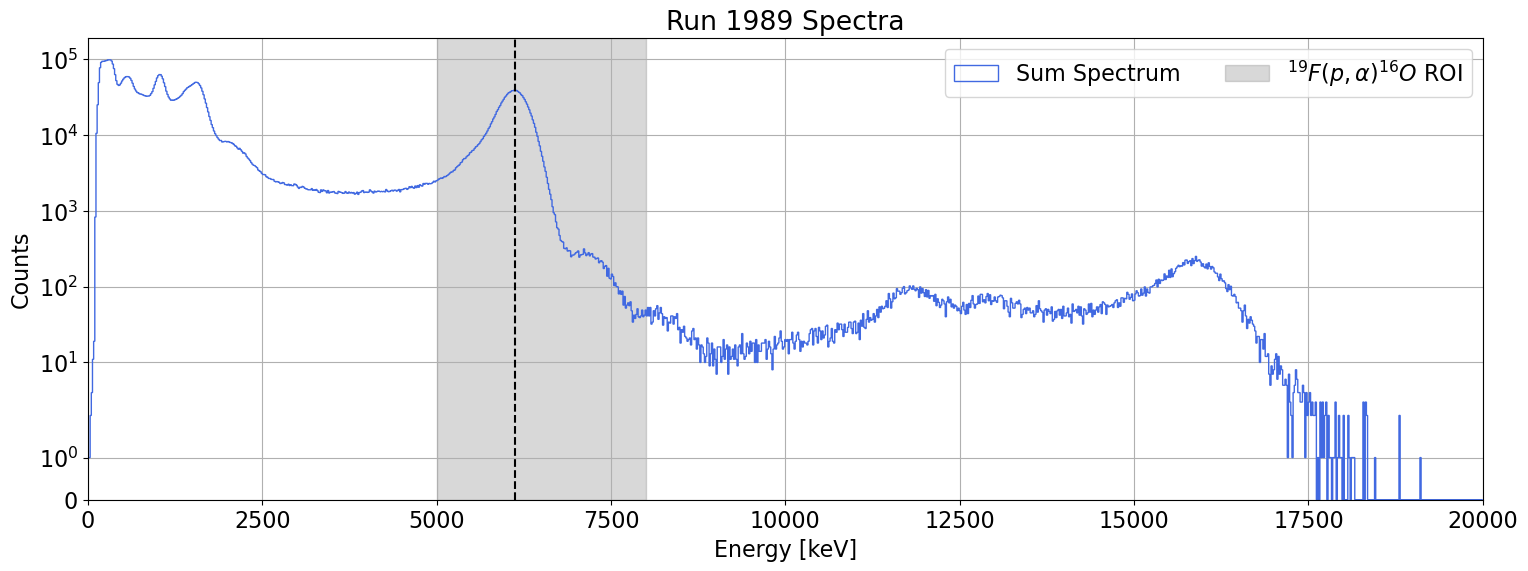

In [26]:
#=================================================#
#   Plot Single Crystals & Sum Spectrum Spectra   #
#=================================================#

from re import X
from turtle import color

from numpy import left_shift


plt.figure(figsize=(18, 6))

plt.title(f'Run {RUN} Spectra')

plt.yscale('symlog')

hist = plt.hist(events["energySum"], bins=np.linspace(1, 20000, 1200), histtype='step', color='royalblue', linewidth = 1, label='Sum Spectrum')

# width = 50
# left_side, x0, y0, right_side, x1, y1, central_side, bkg = covel(hist, ROI_min, ROI_max, width=width)
# plt.axvspan(ROI_min - width, ROI_min, color='red', alpha=0.3)
# plt.axvspan(ROI_max, ROI_max + width, color='red', alpha=0.3)
# plt.scatter(x0, y0, color='deeppink')
# plt.scatter(x1, y1, color='deeppink')
# plt.bar(hist[1][central_side], bkg, width=hist[1][1]-hist[1][0], color='deeppink', alpha=0.25, label='Covel Background', align='edge')
# plt.plot(np.linspace(ROI_min, ROI_max, 10), np.linspace(y0, y1, 10), color='deeppink', ls='--')
# print("Estimated background counts in ROI:", np.sum(bkg))
# # Enlarge central_side by 1 value in both directions
# central_side = np.arange(central_side[0] - 1, central_side[-1] + 2)

# # Recalculate background for the enlarged central_side
# bkg = []
# for i in central_side:
#     bkg.append(y0 + (y1 - y0) / (x1 - x0) * (hist[1][i] - x0))

# print("Total counts in ROI:", np.sum(hist[0][central_side]))
# print("Net counts in ROI:", np.sum(hist[0][central_side]) - np.sum(bkg))

plt.axvline(6128, color='black', ls='--')
plt.axvspan(ROI_min, ROI_max, color='gray', alpha=0.3, label=r'${}^{19}F(p,\alpha){}^{16}O$ ROI')

plt.xlabel('Energy [keV]')
plt.ylabel('Counts')

plt.xlim(0, 20000)
plt.ylim(0, None)

plt.grid()
plt.legend(loc='upper right', ncols=2)

plt.savefig(f'Run{RUN}_SumSpectrum.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
###################################
#   Recover the run infornation   #
###################################

import pandas as pd

if RUN<550:
    df = pd.read_excel('/data0/biasissi/LUNA/19F+p_g+20Ne/19F+p_400kV.xlsx', sheet_name='Beamtime 1')
elif RUN>550 and RUN<1230:
    df = pd.read_excel('/data0/biasissi/LUNA/19F+p_g+20Ne/19F+p_400kV.xlsx', sheet_name='Beamtime 2')
elif RUN>1230 and RUN<2120:
    df = pd.read_excel('/data0/biasissi/LUNA/19F+p_g+20Ne/19F+p_400kV.xlsx', sheet_name='Beamtime 3')
elif RUN>2120 and RUN<2786:
    df = pd.read_excel('/data0/biasissi/LUNA/19F+p_g+20Ne/19F+p_400kV.xlsx', sheet_name='Beamtime 4')
else:
    print("Run number out of range! Check the excel file")

df = df.loc[df['Run Number'] == RUN]
print(df)
target = df['Target'].values[0]
scan = df['Run Type'].values[0]
charge = df['Charge'].values[0]
energy = df['Energy'].values[0]
print(f"Run {RUN} info: Target = {target}, Scan = {scan}, Charge = {charge} C, Energy = {energy} keV")

     Run Number  Run Type     Target       TV      PV  Energy  \
542        1989  Long Run  IMP_LFE#2  203.863  2955.0     NaN   

                 Start Time                   Stop Time Current    Pulser  \
542 1970-01-01 01:00:25.569  1970-01-01 01:00:25.569000     176  767723.0   

     ROI (BGO1)  BGO 1 COUNTS   Counts Error       Charge  Yield  Yield Error  \
542  9500-11500       193743.0           NaN  11931122.31    NaN          NaN   

    Unnamed: 16  
542         NaN  
Run 1989 info: Target = IMP_LFE#2, Scan = Long Run, Charge = 11931122.31 C, Energy = nan keV


In [28]:
################################
#   Compute the yield in ROI   #
################################

# y = np.sum(hist[0][central_side]) - np.sum(bkg)
y = np.sum((events["energySum"] >= ROI_min) & (events["energySum"] <= ROI_max))
y_err = np.sqrt(y)
print(y, y_err)
print(type(y), type(charge))
y, y_err = y/charge, y_err/charge

print(f'Yield in ROI [{ROI_min}, {ROI_max}] keV: {y} +/- {y_err} counts')

# Run,Target,Scan,Energy,Y,Y_error,Charge
# 581,IMP_LTA#1,Scan 1,220.4095297,0.22162431176018435,0.00012580485897373646,14003047.741170058
print(f"{RUN},{target},{scan},{energy},{y},{y_err},{charge}")

1408107 1186.6368441945497
<class 'ROOT._pythonization._rdf_utils.ndarray'> <class 'numpy.float64'>
Yield in ROI [5000, 8000] keV: 0.1180196601303637 +/- 9.945726926292399e-05 counts
1989,IMP_LFE#2,Long Run,nan,0.1180196601303637,9.945726926292399e-05,11931122.31
